# CartPole Random Baseline

## 实验目标

这个 notebook 不训练任何策略，也不使用强化学习算法。它的目标是先展示在 CartPole 这种连续状态、离散动作的平衡控制任务里，如果完全随机地左右施力，小车和杆通常会在多短时间内失去平衡。这个 baseline 会作为后续 `Double DQN` notebook 的参照，用来说明为什么仅靠随机动作无法形成稳定控制策略。


## 环境背景

CartPole 是经典的倒立摆平衡任务。智能体需要控制小车左右移动，使上方杆始终保持接近竖直，同时避免小车越界。虽然动作只有“向左推”和“向右推”两种，但状态是连续的，系统动态也具有明显时序依赖。

这个环境适合用来说明：当状态不再是简单离散格子时，表格方法很快就不够用了，需要引入函数近似来学习更平滑的决策边界。


## 方法说明

这里的方法就是纯随机动作采样：每一步直接从动作空间中随机选择动作，不维护价值函数，也不更新策略。它不是正式算法，但它能非常直观地说明这个环境为什么需要连续状态下的稳定控制逻辑。


## 设备与并行说明

- 本实验默认使用 `CPU`
- 不使用 `CUDA` 或 `MPS`
- 不启用并行环境

原因是这个 notebook 主要做的是环境交互统计，不涉及神经网络训练。


In [1]:
from pathlib import Path

import gymnasium as gym
import imageio.v2 as imageio
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from tqdm.auto import tqdm


In [2]:
ENV_ID = "CartPole-v1"
NUM_EPISODES = 500
MAX_STEPS = 500
ROLLOUT_EPISODES = 3
ROLLOUT_FPS = 30
SEED = 42
SUCCESS_THRESHOLD = 475

RESULTS_DIR = Path("results")
RESULTS_DIR.mkdir(exist_ok=True)

env = gym.make(ENV_ID)


## 参数选择说明

- `NUM_EPISODES = 500`：足够稳定地观察随机控制下的典型表现
- `MAX_STEPS = 500`：与 `CartPole-v1` 的标准回合上限一致
- `ROLLOUT_EPISODES = 3`：保存 3 组随机回放，方便直观看到失稳形态
- `SUCCESS_THRESHOLD = 475`：把接近满分回合作为稳定平衡的近似标准

这里的重点不是训练，而是建立一个清晰的控制基线：随机动作会让回合很短，稳定平衡几乎不可能出现。


In [3]:
episode_rewards = []
episode_lengths = []
successes = []

for episode in tqdm(range(NUM_EPISODES), desc="Random episodes"):
    obs, info = env.reset(seed=SEED + episode)
    total_reward = 0.0

    for step in range(MAX_STEPS):
        action = env.action_space.sample()
        obs, reward, terminated, truncated, info = env.step(action)
        total_reward += reward
        if terminated or truncated:
            episode_lengths.append(step + 1)
            successes.append(int(step + 1 >= SUCCESS_THRESHOLD))
            break
    else:
        episode_lengths.append(MAX_STEPS)
        successes.append(int(MAX_STEPS >= SUCCESS_THRESHOLD))

    episode_rewards.append(total_reward)

env.close()


Random episodes:   0%|          | 0/500 [00:00<?, ?it/s]

In [4]:
summary = pd.DataFrame(
    {
        "reward": episode_rewards,
        "episode_length": episode_lengths,
        "success": successes,
    }
)
summary.describe(include="all")


,reward,episode_length,success
count,500.000000,500.000000,500.0
mean,22.444000,22.444000,0.0
std,12.006965,12.006965,0.0
min,8.000000,8.000000,0.0
25%,14.000000,14.000000,0.0
50%,19.000000,19.000000,0.0
75%,26.000000,26.000000,0.0
max,78.000000,78.000000,0.0


In [5]:
avg_reward = float(np.mean(episode_rewards))
avg_length = float(np.mean(episode_lengths))
success_rate = float(np.mean(successes))

metrics = pd.DataFrame(
    {
        "metric": ["average_reward", "average_episode_length", "success_rate"],
        "value": [avg_reward, avg_length, success_rate],
    }
)
metrics


,metric,value
0,average_reward,22.444
1,average_episode_length,22.444
2,success_rate,0.000


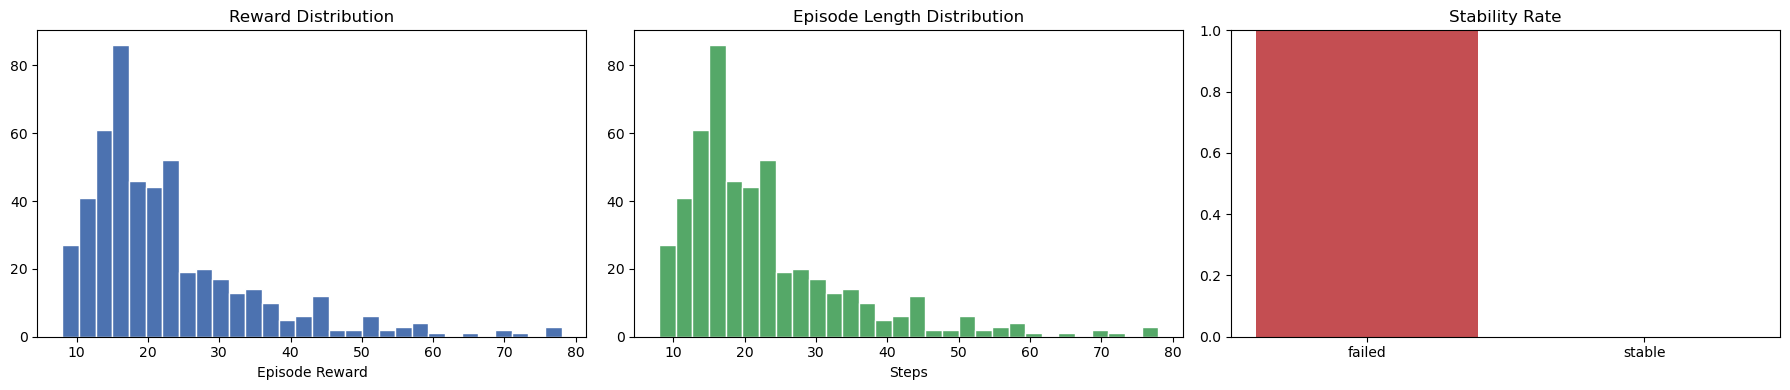

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

axes[0].hist(episode_rewards, bins=30, color="#4c72b0", edgecolor="white")
axes[0].set_title("Reward Distribution")
axes[0].set_xlabel("Episode Reward")

axes[1].hist(episode_lengths, bins=30, color="#55a868", edgecolor="white")
axes[1].set_title("Episode Length Distribution")
axes[1].set_xlabel("Steps")

axes[2].bar(["failed", "stable"], [1 - success_rate, success_rate], color=["#c44e52", "#8172b3"])
axes[2].set_title("Stability Rate")
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(RESULTS_DIR / "random_baseline_overview.png", dpi=150, bbox_inches="tight")
plt.show()


In [7]:
rollout_summaries = []
for rollout_idx in range(ROLLOUT_EPISODES):
    rollout_env = gym.make(ENV_ID, render_mode="rgb_array")
    obs, info = rollout_env.reset(seed=SEED + 1000 + rollout_idx)
    frames = []
    total_reward = 0.0

    for step in range(MAX_STEPS):
        frame = rollout_env.render()
        if frame is not None:
            frames.append(frame)

        action = rollout_env.action_space.sample()
        obs, reward, terminated, truncated, info = rollout_env.step(action)
        total_reward += reward

        if terminated or truncated:
            final_frame = rollout_env.render()
            if final_frame is not None:
                frames.append(final_frame)
            rollout_summaries.append(
                {
                    "rollout_index": rollout_idx + 1,
                    "seed": SEED + 1000 + rollout_idx,
                    "total_reward": total_reward,
                    "steps": step + 1,
                }
            )
            break

    rollout_env.close()
    if frames:
        imageio.mimsave(RESULTS_DIR / f"random_baseline_rollout_{rollout_idx + 1}.gif", frames, fps=ROLLOUT_FPS)

metrics.to_csv(RESULTS_DIR / "random_baseline_metrics.csv", index=False)
summary.to_csv(RESULTS_DIR / "random_baseline_episode_summary.csv", index=False)
pd.DataFrame(rollout_summaries).to_csv(RESULTS_DIR / "random_baseline_rollout_summary.csv", index=False)

print(f"Average reward: {avg_reward:.2f}")
print(f"Average episode length: {avg_length:.2f}")
print(f"Success rate: {success_rate:.4f}")
print(f"Saved results to: {RESULTS_DIR.resolve()}")


Average reward: 22.44
Average episode length: 22.44
Success rate: 0.0000
Saved results to: /Users/bizi/Desktop/GitHub/openai-gym-reinforcement-learning-lab/experiments/08-cartpole-double-dqn/results


## 结果解读

随机策略在 CartPole 里通常很快失去平衡，平均回合长度会很短，稳定维持到回合上限的比例接近于零。这说明这个任务的关键不是单次动作是否正确，而是能否持续做出一串彼此协调的微调控制。
